## Simple Linear Regression

In [15]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
# save the model
import pickle
# create folder to save the model if exists remove it
import os

In [2]:
# import the data
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


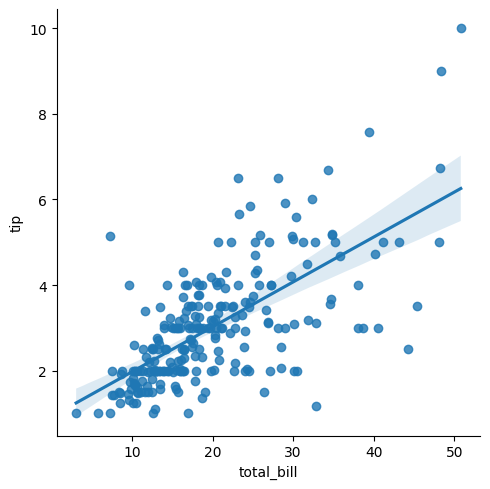

In [3]:
sns.lmplot(x='total_bill', y='tip', data=df)

In [4]:
# preprocess the data
scalar = StandardScaler()
df[['total_bill', 'tip']] = scalar.fit_transform(df[['total_bill', 'tip']])
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,-0.314711,-1.439947,Female,No,Sun,Dinner,2
1,-1.063235,-0.969205,Male,No,Sun,Dinner,3
2,0.137780,0.363356,Male,No,Sun,Dinner,3
3,0.438315,0.225754,Male,No,Sun,Dinner,2
4,0.540745,0.443020,Female,No,Sun,Dinner,4


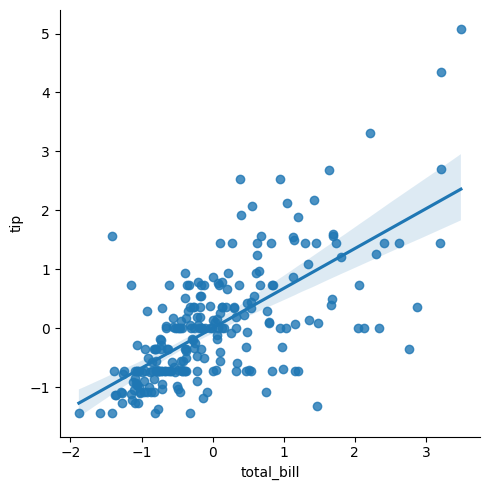

In [5]:
sns.lmplot(x='total_bill', y='tip', data=df)

In [7]:
# separate the features X and the target/labels y
X = df[['total_bill']]
y = df['tip']

print("X:", X)
print("y:", y)

X:      total_bill
0     -0.314711
1     -1.063235
2      0.137780
3      0.438315
4      0.540745
..          ...
239    1.040511
240    0.832275
241    0.324630
242   -0.221287
243   -0.113229

[244 rows x 1 columns]
y: 0     -1.439947
1     -0.969205
2      0.363356
3      0.225754
4      0.443020
         ...   
239    2.115963
240   -0.722971
241   -0.722971
242   -0.904026
243    0.001247
Name: tip, Length: 244, dtype: float64


In [8]:
# train test split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [9]:
# call the model
model = LinearRegression()

In [10]:
%%time
# train the model
model.fit(X_train, y_train)

CPU times: total: 0 ns
Wall time: 146 ms


LinearRegression()

In [11]:
model.predict([[15]])

c:\Users\malik\.conda\envs\python_ml\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([10.35454829])

In [12]:
# prediction
y_pred = model.predict(X_test)

In [14]:
# Evaluate the Model
print('MSE: ', mean_squared_error(y_test, y_pred))
print('R2: ', r2_score(y_test, y_pred))
print('MAPE: ', mean_absolute_percentage_error(y_test, y_pred))
print('MAE: ', mean_absolute_error(y_test, y_pred))
# root mean squared error
print('RMSE: ', np.sqrt(mean_squared_error(y_test, y_pred)))

MSE:  0.2983382530785567
R2:  0.5449381659234667
MAPE:  7.369211703304975
MAE:  0.4496364577054319
RMSE:  0.5462034905404365


## Save the Model

In [17]:
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')
# save the model
pickle.dump(model, open('./saved_models/01_Simple_linear_regression.pkl', 'wb'))

In [18]:
# load the model
# import pickle
model_load = pickle.load(open('./saved_models/01_Simple_linear_regression.pkl', 'rb'))
model_load.predict([[1500.5]])

c:\Users\malik\.conda\envs\python_ml\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1032.69194685])

---